In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

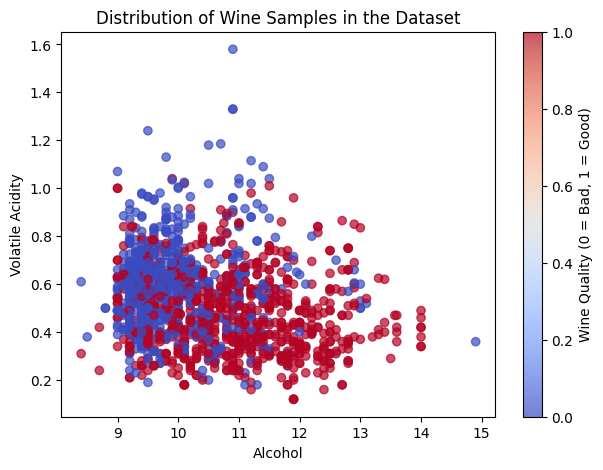

In [5]:
plt.figure(figsize=(7,5))
scatter = plt.scatter(
    df['alcohol'],
    df['volatile acidity'],
    c=df['quality'],
    cmap='coolwarm',
    alpha=0.7
)
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("Distribution of Wine Samples in the Dataset")
plt.colorbar(scatter, label="Wine Quality (0 = Bad, 1 = Good)")
plt.show()

In [6]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (IMPORTANT for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Linear Kernel Tuning
# Expanded C values to explore a broader regularization range
linear_params = {'C': [0.01, 0.1, 1, 10, 100, 500]}
linear_grid = GridSearchCV(SVC(kernel='linear'), linear_params, cv=5)
linear_grid.fit(X_train, y_train)

linear_model = linear_grid.best_estimator_

# RBF Kernel Tuning
# Expanded C and gamma values for a more thorough search
rbf_params = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1, 1]}
rbf_grid = GridSearchCV(SVC(kernel='rbf'), rbf_params, cv=5)
rbf_grid.fit(X_train, y_train)

rbf_model = rbf_grid.best_estimator_

In [8]:
y_pred_linear = linear_model.predict(X_test)
y_pred_rbf = rbf_model.predict(X_test)

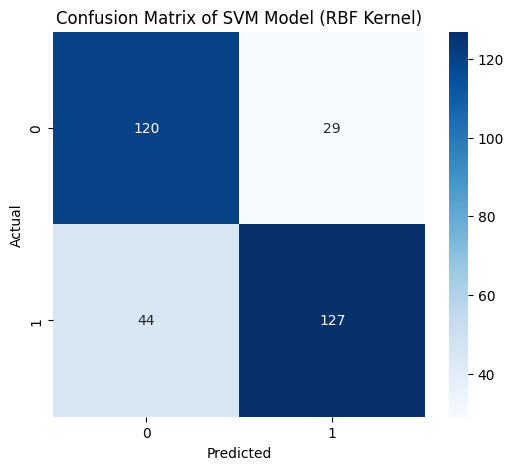

In [9]:
cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix of SVM Model (RBF Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
linear_acc = accuracy_score(y_test, y_pred_linear) * 100
rbf_acc = accuracy_score(y_test, y_pred_rbf) * 100

print(f"Linear Kernel Accuracy: {linear_acc:.2f}%")
print(f"RBF Kernel Accuracy: {rbf_acc:.2f}%")

Linear Kernel Accuracy: 74.06%
RBF Kernel Accuracy: 77.19%


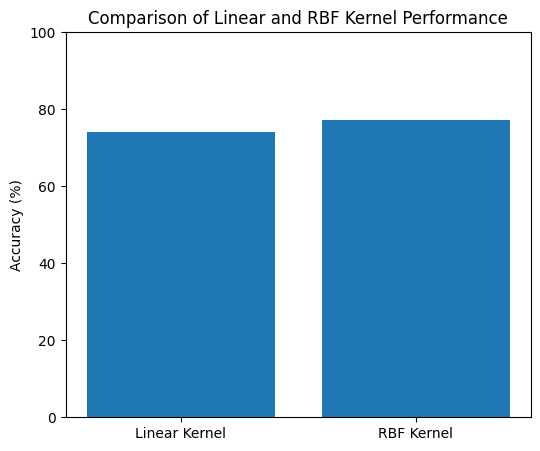

In [11]:
plt.figure(figsize=(6,5))
plt.bar(['Linear Kernel', 'RBF Kernel'], [linear_acc, rbf_acc])
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Linear and RBF Kernel Performance")
plt.ylim(0, 100)
plt.show()